#### DS205 - Project 3

Project: Graph-Based Song Recommendations Using Spotify Audio Feature Vectors 

Team Members: Allan Minn, Andrew Moore, Belinda Xu, Ridge Coughlin

Github Repo: 

Dataset: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

Graph Algorithms: Louvain Modularity, Degree Centrality, Betweenness Centrality, Shortest Path

Objective: A graph-based recommender that moves from familiar songs to new genres by following natural transition paths in the graph

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

from neo4j import GraphDatabase

spotify_df = pd.read_csv("./dataset.csv", index_col=0)

### EDA

In [7]:
print(spotify_df.shape)
print(spotify_df.dtypes)
spotify_df.head()

(114000, 20)
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
# handle missing data
spotify_df.isnull().sum().sort_values(ascending=False)

album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
loudness            0
mode                0
key                 0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

In [9]:
spotify_df = spotify_df.dropna(subset=['album_name'])

In [10]:
# verify if track_id is a good unique identifier
trackid_dupes = spotify_df['track_id'].duplicated().sum()
print(trackid_dupes)

# investigate duplicates
trackid_dupes = spotify_df[spotify_df['track_id'].duplicated(keep=False)]
print(trackid_dupes.sort_values('track_id'))

24259
                      track_id            artists  \
15028   001APMDOl3qtx1526T11n1  Pink Sweat$;Kirby   
103211  001APMDOl3qtx1526T11n1  Pink Sweat$;Kirby   
85578   001YQlnDSduXd5LgBd66gT        Soda Stereo   
100420  001YQlnDSduXd5LgBd66gT        Soda Stereo   
91801   003vvx7Niy0yvhvHt4a68B        The Killers   
...                        ...                ...   
72679   7zv2vmZq8OjS54BxFzI2wM             Attila   
22326   7zv2vmZq8OjS54BxFzI2wM             Attila   
2004    7zwn1eykZtZ5LODrf7c0tS  The Neighbourhood   
3100    7zwn1eykZtZ5LODrf7c0tS  The Neighbourhood   
91401   7zwn1eykZtZ5LODrf7c0tS  The Neighbourhood   

                                             album_name  \
15028                                           New RnB   
103211                                          New RnB   
85578                          Soda Stereo (Remastered)   
100420                         Soda Stereo (Remastered)   
91801                                          Hot Fuss   
...

In [11]:
# remove track_id duplicates (same song across different album versions) keeping most popular one
spotify_df.sort_values(by='popularity', ascending=False, inplace=True) 
spotify_df.drop_duplicates(subset='track_id', inplace=True)

# remove duplicate (track_name, artist) pairs
spotify_df.drop_duplicates(subset=['track_name','artists'], inplace=True)
spotify_df.reset_index(drop=True, inplace=True)

spotify_df.shape

(81343, 20)

In [12]:
# circular encoding for key (0-11) to preserve circular musical relationship
# e.g. key 11 (B) should be close to key 0 (C), not far away
spotify_df['key_sin'] = np.sin(2 * np.pi * spotify_df['key'] / 12)
spotify_df['key_cos'] = np.cos(2 * np.pi * spotify_df['key'] / 12)

# audio feature vectors for KNN graph construction
# mode is binary (0/1) so no encoding needed
song_features = spotify_df[[
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'mode', 'key_sin', 'key_cos'
]]
song_features.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,mode,key_sin,key_cos
count,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,8.134300e+04
mean,0.559289,0.634911,-8.598167,0.088984,0.329697,0.184747,0.219746,0.463311,122.134904,0.632531,-0.029960,3.998929e-02
std,0.177738,0.258637,5.305659,0.116619,0.339951,0.331606,0.198264,0.263408,30.123005,0.482119,0.677089,7.342108e-01
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000e+00
25%,0.446000,0.455000,-10.456000,0.036100,0.015900,0.000000,0.098600,0.241000,99.377500,0.000000,-0.500000,-8.660254e-01
50%,0.573000,0.678000,-7.267000,0.049100,0.190000,0.000089,0.133000,0.449000,122.028000,1.000000,0.000000,-1.836970e-16
75%,0.690000,0.856500,-5.143000,0.087000,0.629000,0.153000,0.283000,0.676000,140.124000,1.000000,0.500000,8.660254e-01
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,1.000000,1.000000,1.000000e+00


### Correlation heatmap

In [13]:
# correlation heatmap
corr = song_features.corr().style.background_gradient(cmap='Blues')
corr

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,mode,key_sin,key_cos
danceability,1.000000,0.134697,0.264937,0.108365,-0.167839,-0.191638,-0.132613,0.491963,-0.015096,-0.059053,-0.034523,0.007643
energy,0.134697,1.000000,0.761065,0.139930,-0.731064,-0.186146,0.191130,0.253539,0.260598,-0.069421,-0.035227,0.004241
loudness,0.264937,0.761065,1.000000,0.054231,-0.582038,-0.433946,0.080548,0.289285,0.233762,-0.035492,-0.024631,-0.005324
speechiness,0.108365,0.139930,0.054231,1.000000,0.012264,-0.107059,0.231638,0.035096,-0.003374,-0.035776,-0.005013,0.004164
acousticness,-0.167839,-0.731064,-0.582038,0.012264,1.000000,0.095007,-0.016476,-0.101561,-0.223376,0.083872,0.041782,-0.016038
instrumentalness,-0.191638,-0.186146,-0.433946,-0.107059,0.095007,1.000000,-0.096646,-0.332371,-0.058773,-0.050358,0.002965,0.006727
liveness,-0.132613,0.191130,0.080548,0.231638,-0.016476,-0.096646,1.000000,0.014618,-0.009005,0.018401,0.010416,-0.005069
valence,0.491963,0.253539,0.289285,0.035096,-0.101561,-0.332371,0.014618,1.000000,0.093250,0.024246,-0.036148,-0.004013
tempo,-0.015096,0.260598,0.233762,-0.003374,-0.223376,-0.058773,-0.009005,0.093250,1.000000,-0.001761,-0.011777,0.002151
mode,-0.059053,-0.069421,-0.035492,-0.035776,0.083872,-0.050358,0.018401,0.024246,-0.001761,1.000000,0.025943,0.029273


In [14]:
# standardize features to same scale
scaler = StandardScaler()
spotify_scaled = scaler.fit_transform(song_features)

# apply feature weights after scaling
# higher weight = more influence on KNN similarity
# energy and tempo weighted up: most perceptually jarring when mismatched
# valence weighted up: mood is strongly felt by listeners
# liveness, key, mode weighted down: less perceptually salient
feature_weights = {
    'danceability':     1.0,
    'energy':           1.5,
    'loudness':         1.0,
    'speechiness':      1.0,
    'acousticness':     1.0,
    'instrumentalness': 1.0,
    'liveness':         0.5,
    'valence':          1.2,
    'tempo':            1.5,
    'mode':             0.8,
    'key_sin':          0.5,
    'key_cos':          0.5,
}

weights = np.array([feature_weights[f] for f in song_features.columns])
spotify_scaled_weighted = spotify_scaled * weights

# validate scaled values
spotify_scaled_df = pd.DataFrame(spotify_scaled_weighted, columns=song_features.columns)
spotify_scaled_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,mode,key_sin,key_cos
0,0.870451,-0.944828,0.230542,-0.022162,-0.931603,-0.557117,0.116648,-1.026448,0.447473,0.609760,0.661649,0.313271
1,0.347205,0.853071,0.574893,-0.385742,-0.933074,-0.457615,0.025859,0.394932,0.293702,0.609760,0.661649,0.313271
2,1.551233,0.255704,0.616170,-0.450912,0.745120,-0.557125,-0.004404,1.761643,0.141675,-1.049593,-0.347106,-0.617003
3,0.009627,1.914412,0.928291,-0.468919,-0.958578,-0.557110,0.381447,-0.725772,0.294051,-1.049593,-0.347106,-0.617003
4,0.510368,0.464493,0.640861,1.406434,-0.677741,-0.556254,-0.236419,-1.258789,-0.769993,-1.049593,0.391354,-0.617003


### Genre similarity analysis

In [15]:
# Select the audio feature columns for genre analysis
# using the same feature set as KNN for consistency
genre_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'mode', 'key_sin', 'key_cos'
]

# Group by genre and get the mean of these features
genre_means = spotify_df.groupby('track_genre')[genre_features].mean()

# standardize genre profiles
scaler = StandardScaler()
genre_means_scaled = scaler.fit_transform(genre_means)

# compute cosine similarity between genre profiles
similarity_matrix = cosine_similarity(genre_means_scaled)
similarity_df = pd.DataFrame(similarity_matrix, index=genre_means.index, columns=genre_means.index)

similarity_df.head()

track_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,...,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
track_genre,,,,,,,,,,,,,,,,,,,,,
acoustic,1.000000,-0.516768,-0.463170,-0.314612,0.359863,-0.548750,-0.382881,0.446192,0.306808,-0.023186,...,-0.223036,0.017370,0.284144,-0.058764,0.160722,-0.471767,-0.653990,-0.427498,-0.511095,0.611436
afrobeat,-0.516768,1.000000,0.544310,0.371794,-0.237976,0.251010,-0.320591,0.125107,0.480182,0.067003,...,0.389978,0.247928,0.338783,0.008734,0.180209,0.346718,0.194790,0.575779,0.509158,-0.907741
alt-rock,-0.463170,0.544310,1.000000,0.587325,-0.405506,0.048527,0.149480,0.212708,0.454216,0.206038,...,0.543588,-0.489893,0.473805,-0.052593,-0.130476,0.294664,0.348836,-0.010786,0.239260,-0.519907
alternative,-0.314612,0.371794,0.587325,1.000000,-0.645137,-0.045114,-0.039051,-0.356737,0.493378,0.235790,...,0.676442,-0.321581,0.409058,0.337392,-0.349522,0.070573,0.159499,0.206337,0.437586,-0.296539
ambient,0.359863,-0.237976,-0.405506,-0.645137,1.000000,0.417220,0.107694,0.120271,-0.261380,-0.342866,...,-0.895526,0.535087,-0.500013,-0.420935,0.579535,0.020996,-0.186699,0.055410,-0.059798,0.222069


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 2000x2000 with 0 Axes>

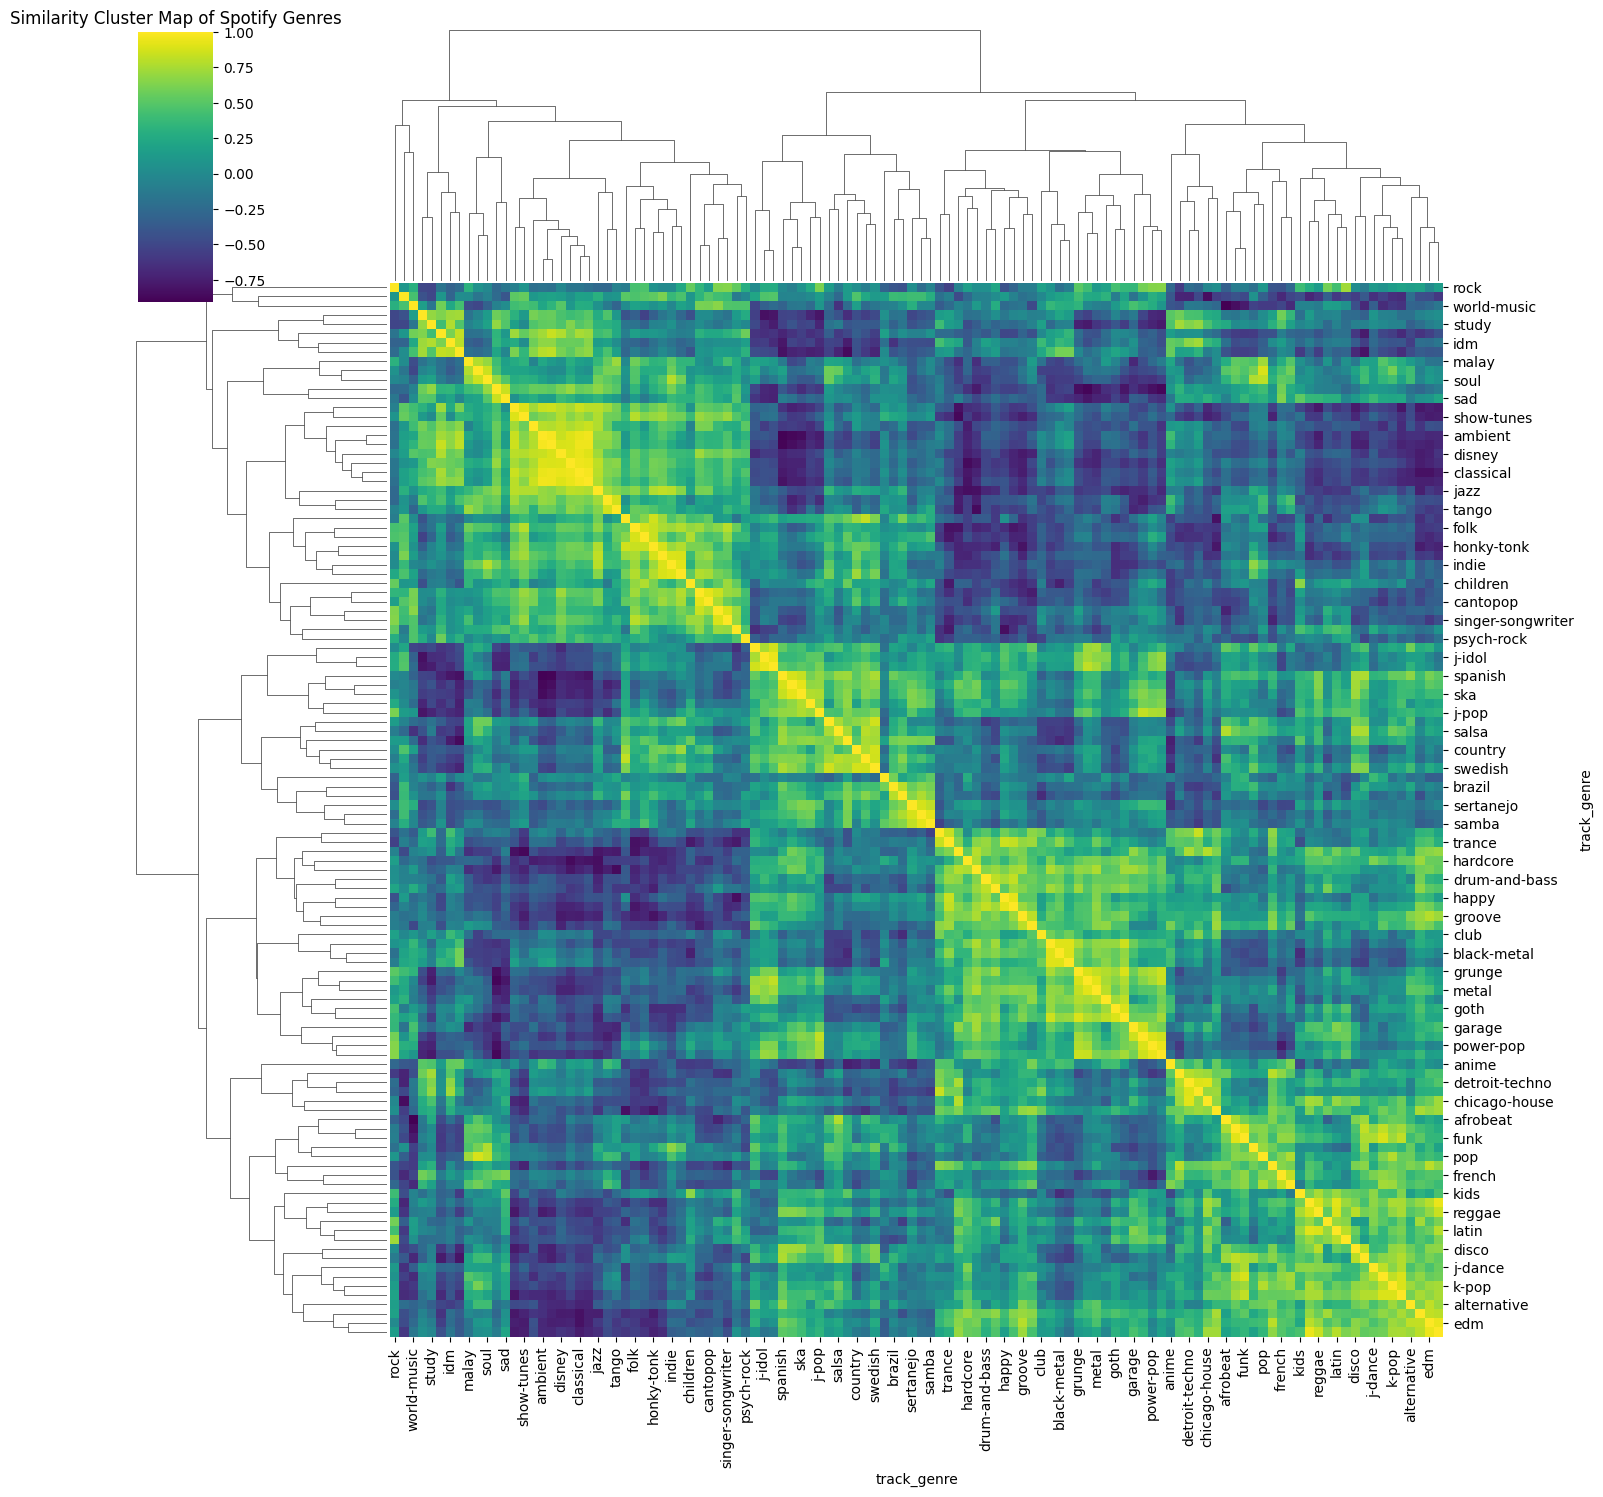

In [16]:
plt.figure(figsize=(20, 20))
sns.clustermap(similarity_df, cmap='viridis', figsize=(15, 15))
plt.title('Similarity Cluster Map of Spotify Genres')
plt.show()

In [17]:
print('Least similar to show-tunes:')
print(similarity_df['show-tunes'].sort_values(ascending=True).head(6))

Least similar to show-tunes:
track_genre
breakbeat       -0.874038
edm             -0.764948
house           -0.747207
groove          -0.744543
chicago-house   -0.732218
deep-house      -0.722104
Name: show-tunes, dtype: float64


In [18]:
print('Most similar to show-tunes:')
print(similarity_df['show-tunes'].sort_values(ascending=False).head(6))

Most similar to show-tunes:
track_genre
show-tunes    1.000000
opera         0.900343
folk          0.784274
disney        0.782561
jazz          0.771254
classical     0.739743
Name: show-tunes, dtype: float64


# Build Initial Graph

In [19]:
# neo4j helper functions

# define neo4j connection
driver = GraphDatabase.driver(
    'bolt://127.0.0.1:7687',
    auth=('neo4j','205spotify'))

session = driver.session(database="neo4j")

# convert results to pandas dataframe
def my_neo4j_run_query_pandas(query, **kwargs):
    with driver.session(database="neo4j") as session:
        result = session.run(query, **kwargs)
        df = pd.DataFrame([r.values() for r in result], columns=result.keys())
    return df

# run neo4j query
def neo4j_run(query, **kwargs):
    with driver.session(database="neo4j") as session:
        return session.run(query, **kwargs)

# wipe neo4j graph
# wiping in batches of 5k rows prevents memorypooloutofmemory error when trying to wipe database
def neo4j_batch_wipe(session):
    with driver.session(database="neo4j") as session:
        batch_wipe_query = """
        MATCH (n)
        CALL {
            with n
            detach delete n
        } in transactions of 5000 rows
        """

        session.run(batch_wipe_query)

# drop projection
# run to resolve error caused by projection in memory during previous crash
neo4j_run("CALL gds.graph.drop('song_graph', false) YIELD graphName")

ClientError: {neo4j_code: Neo.ClientError.Database.DatabaseNotFound} {message: Unable to get a routing table for database 'neo4j' because this database does not exist} {gql_status: 22000} {gql_status_description: error: data exception}

In [ ]:
# Build initial Neo4j graph
node_query = """
    UNWIND $rows as row
    MERGE (s:Song {id: row.track_id})
    SET s.track_name = row.track_name,
        s.genre = row.track_genre,
        s.artists = row.artists,
        s.album = row.album_name,
        s.popularity = row.popularity,
        s.danceability = row.danceability,
        s.energy = row.energy,
        s.loudness = row.loudness,
        s.speechiness = row.speechiness,
        s.acousticness = row.acousticness,
        s.instrumentalness = row.instrumentalness,
        s.liveness = row.liveness,
        s.valence = row.valence,
        s.tempo = row.tempo,
        s.mode = row.mode,
        s.key_sin = row.key_sin,
        s.key_cos = row.key_cos
"""

# convert song data to list (neo4j needs this format)
node_list = spotify_df.to_dict('records')

print('Wiping database')
neo4j_batch_wipe(session)

# create index on Song.id before merging to avoid full scans
neo4j_run('CREATE INDEX song_id_index IF NOT EXISTS FOR (s:Song) ON (s.id)')
print('Index created')

print('Create nodes')
session.run(node_query, rows=node_list)

# Create edges using KNN
print('Running KNN')

# L2 normalize weighted features so euclidean distance == cosine distance
# ball_tree with euclidean on normalized vectors is much faster than brute-force cosine
from sklearn.preprocessing import normalize
spotify_normalized = normalize(spotify_scaled_weighted)

knn = NearestNeighbors(n_neighbors=6, metric='euclidean', algorithm='ball_tree')
knn.fit(spotify_normalized)
distances, indices = knn.kneighbors(spotify_normalized)

# convert euclidean distances on normalized vectors back to cosine distance
# for normalized vectors: cosine_dist = euclidean_dist^2 / 2
cos_distances = distances ** 2 / 2

# create list of edges pointing to most similar tracks
edges = []

for i in range(len(spotify_df)):
    src_id = spotify_df.iloc[i]['track_id']

    for j in range(1, 6):
        nbr_idx = indices[i][j]
        nbr_id = spotify_df.iloc[nbr_idx]['track_id']
        cos_dist = float(cos_distances[i][j])

        edges.append({
            'source_id': src_id,
            'target_id': nbr_id,
            'distance': cos_dist,
            'similarity': float(1 - cos_dist)
        })

# convert edge data to dataframe
edges_df = pd.DataFrame(edges)
edges_list = edges_df.to_dict('records')

# run edge query in batches
edge_query = """
    UNWIND $rows AS row
    MATCH (source:Song {id: row.source_id})
    MATCH (target:Song {id: row.target_id})
    MERGE (source)-[r:SIMILAR_TO]->(target)
    SET r.similarity = row.similarity,
        r.distance   = row.distance,
        r.cost = row.distance
"""

batch_size = 5000
for start in range(0, len(edges_list), batch_size):
    batch = edges_list[start:start + batch_size]
    neo4j_run(edge_query, rows=batch)
    print(f'Loaded edges {start} - {start + len(batch)}')

print('Done')

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (n) { ... }', position=<SummaryInputPosition line=3, column=9, offset=27>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 27, 'line': 3, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        MATCH (n)\n        CALL {\n            with n\n            detach delete n\n        } in transactions of 5000 rows\n        '


Wiping database
Create nodes


# Graph Projection

In [ ]:
# drop previous in-memory projection if it exists, then re-project
drop_proj_query = "CALL gds.graph.drop('song_graph', false) YIELD graphName"
neo4j_run(drop_proj_query)

new_proj_query = """
CALL gds.graph.project(
    'song_graph',
    'Song',
    {
        SIMILAR_TO: {
            orientation: 'UNDIRECTED',
            properties: ['similarity', 'cost']
        }
    }
)
YIELD nodeCount, relationshipCount
RETURN nodeCount, relationshipCount
"""

result = my_neo4j_run_query_pandas(new_proj_query)
print(result)

# create text index on track_name for fast search
neo4j_run("CREATE TEXT INDEX song_name_index IF NOT EXISTS FOR (s:Song) ON (s.track_name)")
print("Text index ready")

# Louvain Community Detection

In [ ]:
# run louvain and write community IDs back to nodes in neo4j
lou_write_query = """
CALL gds.louvain.write(
    'song_graph',
    {
        relationshipWeightProperty: 'similarity',
        writeProperty: 'community'
    }
)
YIELD communityCount, modularity
RETURN communityCount, modularity
"""

louvain_write = my_neo4j_run_query_pandas(lou_write_query)
print(f"Communities: {louvain_write['communityCount'][0]}")
print(f"Modularity:  {louvain_write['modularity'][0]:.4f}")

# verify community assignments
louvain_df = my_neo4j_run_query_pandas("""
    MATCH (s:Song)
    WHERE s.community IS NOT NULL
    RETURN s.community AS community
""")
print(f'Total communities: {louvain_df["community"].nunique()}')
print('Community size distribution:')
print(louvain_df.groupby('community').size().describe())

# Betweenness Centrality

In [ ]:
# run approximate betweenness centrality and write scores back to nodes
bw_write_query = """
CALL gds.betweenness.write(
    'song_graph',
    {
        samplingSize: 100,
        samplingSeed: 0,
        writeProperty: 'betweenness'
    }
)
YIELD nodePropertiesWritten
RETURN nodePropertiesWritten
"""

between_write = my_neo4j_run_query_pandas(bw_write_query)
print(between_write)

# inspect top songs by betweenness
top_bw = my_neo4j_run_query_pandas("""
    MATCH (s:Song)
    WHERE s.betweenness IS NOT NULL
    RETURN s.track_name AS track_name, s.artists AS artists, s.betweenness AS betweenness
    ORDER BY s.betweenness DESC
    LIMIT 10
""")
print(top_bw)